### Advanced Human computer Interaction Lab 2 Notebook (CNN)

> **Tip:** Run cells top-to-bottom. If you hit a missing library error, install it in the first “Install” cell.


In [ ]:
# (Optional) Install extras if needed (run only if you get ModuleNotFoundError)
!pip install librosa transformers torch nltk scikit-learn matplotlib


## Lab 1 — Image Classification with a Simple CNN
**Data:** CIFAR link provided, but we will use a directory-based dataset loader.

### Learning outcomes
- Load images from folders
- Normalize pixel values
- Build and train a CNN
- Predict a class for a new image


### 1) Import libraries
We import TensorFlow and Keras layers/models.
- `tensorflow` is the deep learning framework
- `layers` contains building blocks (Conv2D, MaxPooling2D, Dense, ...)
- `models` contains model containers like `Sequential`


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansanagapati/images-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\pavansanagapati\images-dataset\versions\1


### 2) Load and preprocess images

We set:
- `img_size = (128, 128)` → every image will be resized to 128×128
- `batch_size = 32` → how many images per training batch

Then we load the dataset from **`dataset/`** where each subfolder is a class.

`label_mode="categorical"` means labels become **one-hot vectors** (e.g., `[1,0,0]`) which matches `categorical_crossentropy`.


In [2]:
import os
path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pavansanagapati\images-dataset\versions\1\data"
print(os.listdir(path))


['cats', 'dogs']


In [3]:
img_size = (128, 128)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(r"C:\Users\Lenovo\.cache\kagglehub\datasets\pavansanagapati\images-dataset\versions\1\data",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"   # for 3 classes
)

# Quick check: what are the class names?
class_names = train_data.class_names
print("Classes:", class_names)


Found 404 files belonging to 2 classes.
Classes: ['cats', 'dogs']


#### Normalize images (scale pixels to 0..1)
Most images have pixel values in **0..255**.
Neural networks typically train better when inputs are normalized to **0..1**.

`layers.Rescaling(1./255)` does that scaling.

Then we use `.map(...)` to transform each `(x, y)` batch:
- `x` becomes normalized
- `y` stays the same


In [4]:
normalization_layer = layers.Rescaling(1./255)
train_data = train_data.map(lambda x, y: (normalization_layer(x), y))


### 3) Build a simple CNN model

A CNN usually repeats:
1. **Convolution (Conv2D)** → learns features (edges, textures, shapes)
2. **Pooling (MaxPooling2D)** → reduces size and keeps strongest signals

Then we:
- **Flatten** the feature maps into a 1D vector
- Use **Dense** layers for classification
- Output layer uses **softmax** for 3 classes (probabilities sum to 1)


In [7]:

num_classes = len(class_names)
print("Detected classes:", num_classes, class_names)

model = tf.keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model.summary()


Detected classes: 2 ['cats', 'dogs']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
history = model.fit(
    train_data,
    epochs=10
)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5198 - loss: 0.7105
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5817 - loss: 0.6829
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5619 - loss: 0.6795
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6658 - loss: 0.6138
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7178 - loss: 0.5407
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.7772 - loss: 0.4432
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8366 - loss: 0.3659
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8193 - loss: 0.3861
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8738 - loss: 0.3015
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9257 - loss: 0.2072


In [10]:
img_size = (128, 128)
batch_size = 32

dataset_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pavansanagapati\images-dataset\versions\1\data"

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,     # 20% for validation
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)


Found 404 files belonging to 2 classes.
Using 324 files for training.
Found 404 files belonging to 2 classes.
Using 80 files for validation.


In [11]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data   = val_data.map(lambda x, y: (normalization_layer(x), y))


In [12]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9475 - loss: 0.1382 - val_accuracy: 0.9750 - val_loss: 0.1004
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9784 - loss: 0.0779 - val_accuracy: 0.9750 - val_loss: 0.1092
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9969 - loss: 0.0421 - val_accuracy: 0.9625 - val_loss: 0.1082
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9969 - loss: 0.0271 - val_accuracy: 0.9625 - val_loss: 0.1052
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.9500 - val_loss: 0.1210
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9375 - val_loss: 0.2021
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9625 - val_loss: 0.1612
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9375 - v

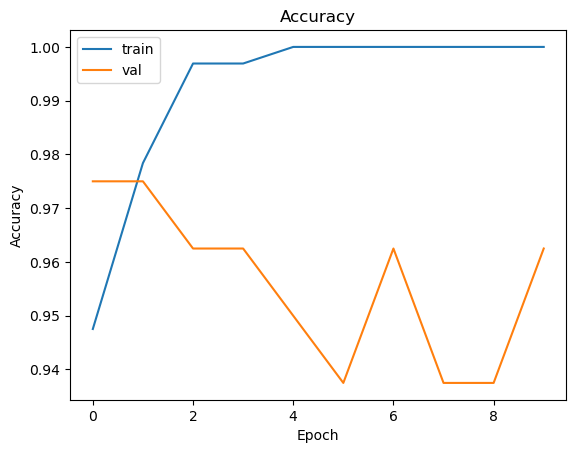

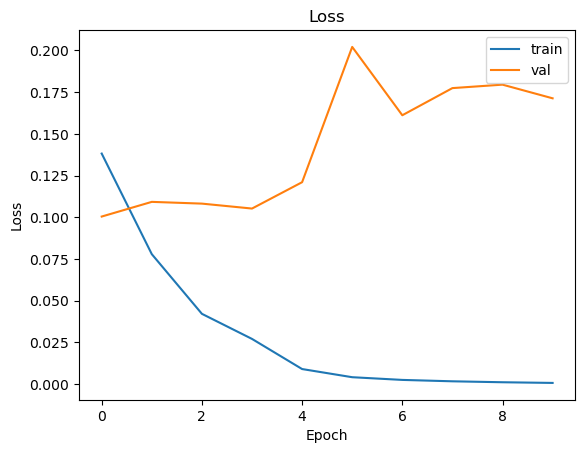

In [13]:
import matplotlib.pyplot as plt
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 6) Print the classification report
Get predictions on your validation set

This assumes:

   1. val_data exists

   2. labels are one-hot (label_mode="categorical")

   3. you have class_names saved (from train_data_raw.class_names)


In [14]:
# !pip install scikit-learn

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images, verbose=0)

    # one-hot -> class index
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,   # list of class names
    digits=4
))



              precision    recall  f1-score   support

        cats     0.9487    0.9737    0.9610        38
        dogs     0.9756    0.9524    0.9639        42

    accuracy                         0.9625        80
   macro avg     0.9622    0.9630    0.9624        80
weighted avg     0.9628    0.9625    0.9625        80



In [15]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[37  1]
 [ 2 40]]


### 7) Predict on a new image

Steps:
1. Load image and resize to `img_size`
2. Convert to array
3. Add a batch dimension (model expects batches)
4. Normalize to 0..1 (divide by 255)
5. `model.predict(...)` returns probabilities per class
6. Use `argmax` to select the most likely class index

We also map the index back to the class name.


Prediction probabilities:
cats: 0.9475
dogs: 0.0525

Predicted class: cats


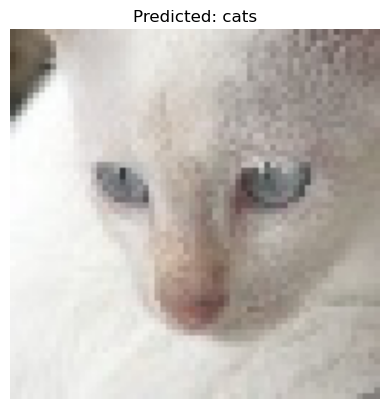

In [19]:
from tensorflow.keras.preprocessing import image
img_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pavansanagapati\images-dataset\versions\1\test\10560.jpg"

# Load image
img = image.load_img(img_path, target_size=img_size)

# Convert to array & normalize
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)
class_index = np.argmax(prediction)

# Print probabilities nicely
print("Prediction probabilities:")
for i, prob in enumerate(prediction[0]):
    print(f"{class_names[i]}: {prob:.4f}")

print("\nPredicted class:", class_names[class_index])

# Show image with prediction
plt.imshow(img)
plt.title(f"Predicted: {class_names[class_index]}")
plt.axis("off")
plt.show()

